<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/NEPSE(NTC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ntc=pd.read_csv("NTCONEYEARCSV.csv")
ntc.shape
ntc.ndim
ntc.head()
ntc.tail()
ntc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          223 non-null    object 
 1   Date            223 non-null    object 
 2   Open            223 non-null    float64
 3   High            223 non-null    float64
 4   Low             223 non-null    float64
 5   Close           223 non-null    float64
 6   Percent Change  223 non-null    object 
 7   Volume          223 non-null    object 
 8   Turn Over       223 non-null    object 
dtypes: float64(4), object(5)
memory usage: 15.8+ KB


In [4]:
ntc["Date"] = pd.to_datetime(ntc["Date"])
ntc["Volume"] =ntc["Volume"].replace("-",np.nan)
ntc["Volume"] = ntc["Volume"].str.replace(",","",regex=False).astype(float)



In [5]:
ntc["Percent Change"]=ntc["Percent Change"].str.replace("%",'',regex=False).str.strip().astype(float)

In [6]:
ntc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Symbol          223 non-null    object        
 1   Date            223 non-null    datetime64[ns]
 2   Open            223 non-null    float64       
 3   High            223 non-null    float64       
 4   Low             223 non-null    float64       
 5   Close           223 non-null    float64       
 6   Percent Change  223 non-null    float64       
 7   Volume          223 non-null    float64       
 8   Turn Over       223 non-null    object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 15.8+ KB


In [7]:
ntc = ntc.drop(columns = ["Symbol","Turn Over"])

In [9]:
ntc=ntc.sort_values("Date").reset_index(drop=True)
ntc.head()

,Date,Open,High,Low,Close,Percent Change,Volume
0,2025-07-08,850.0,850.0,844.0,845.03,-0.44,16713.0
1,2025-07-09,843.0,850.0,842.0,846.55,0.18,11850.0
2,2025-07-10,851.0,855.0,849.0,853.30,0.80,20896.0
3,2025-07-13,860.0,877.0,854.1,858.96,0.66,27361.0
4,2025-07-14,860.0,868.9,858.0,862.55,0.42,22127.0


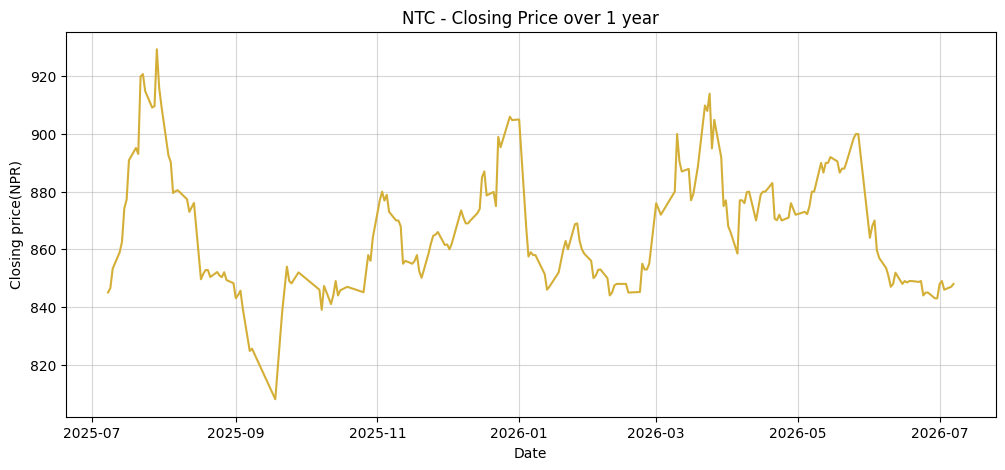

In [10]:
plt.figure(figsize=(12,5))
plt.plot(ntc["Date"],ntc["Close"], color="#D4AF37", linewidth=1.5)
plt.title("NTC - Closing Price over 1 year")
plt.xlabel("Date")
plt.ylabel("Closing price(NPR)")
plt.grid(True , alpha = 0.5)

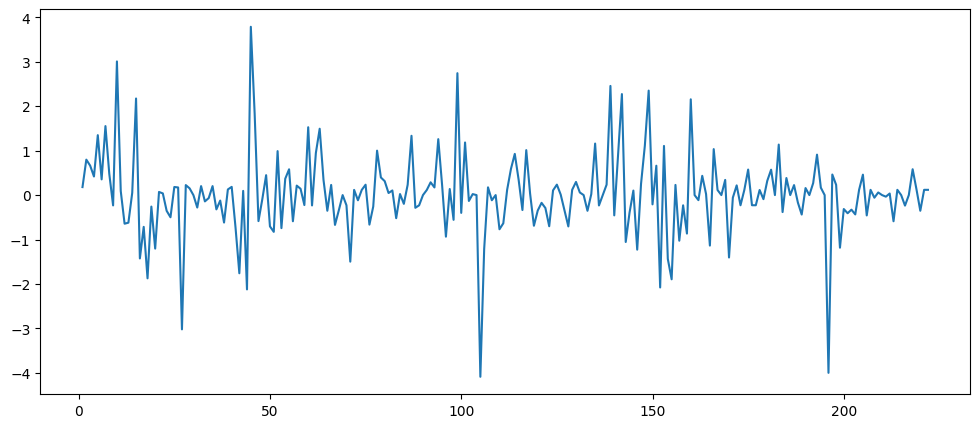

In [11]:
ntc["Daily Return"] = ntc["Close"].pct_change()*100
plt.figure(figsize=(12,5))
plt.plot(ntc["Daily Return"])

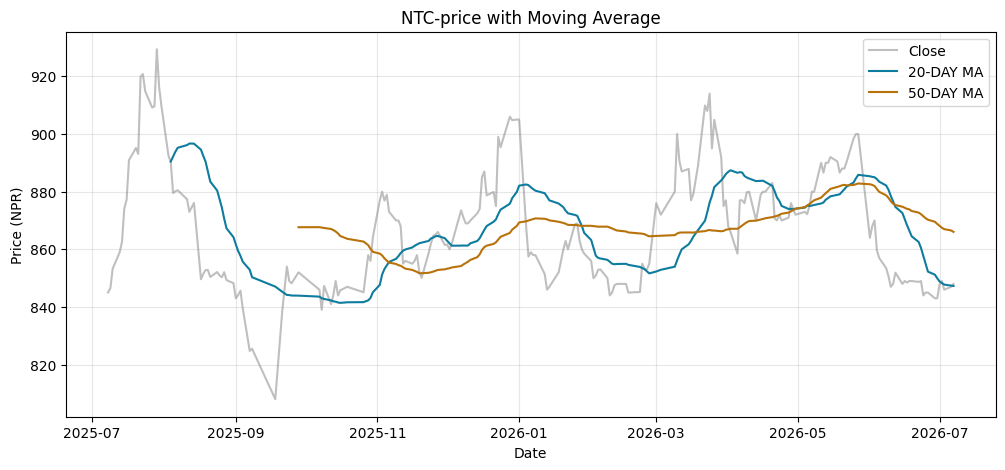

In [12]:
ntc['MA20'] = ntc['Close'].rolling(window=20).mean()
ntc['MA50'] = ntc['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,5))
plt.plot(ntc['Date'], ntc['Close'],label='Close',alpha=0.5, color='gray')
plt.plot(ntc['Date'], ntc['MA20'],label='20-DAY MA',color='#0E7C9E')
plt.plot(ntc['Date'], ntc['MA50'],label='50-DAY MA', color='#B8720A')
plt.title("NTC-price with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (NPR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

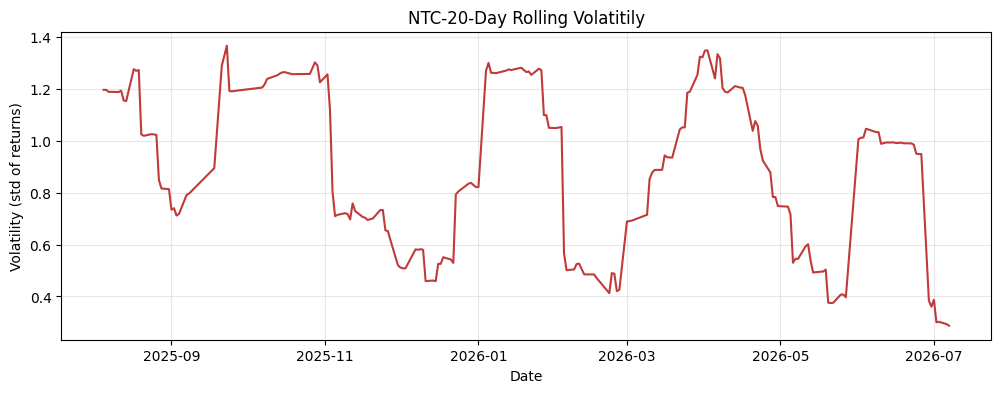

In [13]:
ntc['Volatility'] = ntc["Daily Return"].rolling(window=20).std()

plt.figure(figsize=(12,4))
plt.plot(ntc["Date"],ntc['Volatility'], color ="#C13A3A")
plt.title("NTC-20-Day Rolling Volatitily")
plt.xlabel("Date")
plt.ylabel("Volatility (std of returns)")
plt.grid(True,alpha=0.3)
plt.show()

In [14]:
ntc.to_csv("NTC_CLEAN.csv", index=False)
print("Saved NTC_CLEAN.csv — ready for Day 10")

from google.colab import files
files.download("NTC_CLEAN.csv")


Saved NTC_CLEAN.csv — ready for Day 10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>